<p>
<h1><b><center>Mecánica de Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h2>
<h2><b><center>Tarea 1</center></b><h2>
<h3><b><center>Termalización de un gas</center></b><h3>
</p>

## Enunciado

**Objetivo**: El objetivo de esta tarea es simular el proceso de *termalización* de un gas de partículas monoatómicas y poner a prueba algunos de los principios básicos de la mecánica estadística.

**Procedimiento**:

Para conseguir el objetivo:

1. Partiendo del notebook desarrollado en la clase de Mecánica Estadística generar posiciones al azar para N partículas puntuales, en una caja rectangular de lado L.

2. Para las velocidades, asignar inicialmente a todas las partículas velocidades al azar pero con la misma magnitud, p.e. $v_{0}$ = 1 (en unidades termodinámicas).

3. Definir un paso de tiempo para realizar la simulación del movimiento de las partículas así:

   - Calcular $L_{mol}$ en la caja.
   - El paso de tiempo será $dt = (L_{mol}/v_0)/f_t$ donde $f_t = 10$. Puede hacer más pequeño o más grande $f_t$ de dependiendo de si la simulación tarda mucho tiempo en ejecutarse.

4. Simular el movimiento de las partículas del gas así:

   - Por cada paso de tiempo modificar la posición de las partículas con la velocidad que cada una tenga en un momento dado.

   - Si una partícula se sale por un lado de la caja la partícula debe volver a la caja por el lado opuesto (condiciones de frontera periódicas).

   - En cada paso de tiempo, y por cada partícula, determinar cuál de las demás partículas de la caja esta más cerca. Si la distancia a la que se encuentra la otra partícula es menor que $L_{mol}/f_d$, donde $f_d=10$ asumiremos que las dos partículas chocan y calcularemos el resultado del choque elástico entre ellas. Puede modificar el parámetro $f_d$ de acuerdo a los resultados.

5. Haga un histograma de la rapidez de las partículas cada 100 pasos de tiempo y mire como a medida que se producen los choques va cambiando la distribución de velocidades.

6. Cuando la distribución de velocidades tenga la apariencia de una distribución de Maxwell-Boltzmann, decimos que la simulación o el gas, ha termalizado. Determine la temperatura y la presión del gas usando las leyes que encontramos en clase. La presión no tiene que calcularse usando choques, puede usarse la relación que tiene con la densidad de energía cinética.

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - Varios gráficos con distribución de la rapidez de las partículas durante la simulación.

- Datos mínimos:
  - Valor de la temperatura al final de la simulación.
  - Valor de la presión al final de la simulación.

- Gráficos opcionales:
  - Animación del movimiento de las partículas del gas.
  - Evolución de la temperatura como función del tiempo.
  - Evolución de la presión como función del tiempo.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.

## Errores a corregir

* Muy bien por la generación de velocidades usando ángulos. Sin embargo las velocidades así generadas no están distribuídas uniformemente en la esfera unitaria (-1).

  La temperatura y la presión solo debería calcularse con la ley de equipartición una vez el gas este termalizado (-1)

* No incluir en la misma celda la instalación de un paquete y un comando import, pe. cuando instala celluloid (-1).

* No es necesario incluir todos los experimentos numéricos antes de los resultados (-1).

## Solución


### Unidades Termodinámicas

En la mecánica estadística, la constante básica es la constante de Boltzmann:

$$
k_B = 1.380649\times 10^{-23} \frac{\mathrm{J}}{\mathrm{K}} = 1.380649\times 10^{-23} \frac{\mathrm{kg\;m^2}}{\mathrm{K\;s^2}}
$$

Para elegir un sistema de unidades más conveniente para los cálculos numéricos, asumimos que $k_B = 1$. Con la siguiente fórmula determinamos el escalado de las unidades termodinámicas:

$$
k_B = \frac{U_M U_L^2}{U_T U_t^2}
$$

Para escoger un conjunto apropiado de unidades termodinámicas se debe elegir 3 de las 4 unidades básicas (masa, longitud, temperatura y tiempo). Normalmente está última es la unidad que se deja para determinar.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ======================== Unidades termodinámicas ========================

kB = 1.38e-23     # [kg m^2 / (K s^2)] - Constante de Boltzmann
UM = 1.66e-27     # [kg] - UMA
UL = 1e-9         # [m] - Nanómetro
UT = 300          # [K] - 26,85 °C - Temperatura del gas
KB = 1     # [kB]

Ut = np.sqrt(UM*UL**2/(UT*kB))    # [s] - Unidad de tiempo
UV = UL/Ut        # [m/s] - Unidad de velocidad
URHO = UM/UL**3   # [kg/m^3] - Unidad de densidad
UE = UM*UV**2     # [J] - Unidad de energía
UF = UM*UL/Ut**2  # [N] - Unidad de fuerza
UP = UF/UL**2     # [Pa] - Unidad de presión

print(f"Unidad de tiempo: {Ut:g} s")
print(f"Unidad de velocidad: {UV:g} m/s")
print(f"Unidad de densidad: {URHO:g} kg/m^3")
print(f"Unidad de energía: {UE:g} J")
print(f"Unidad de fuerza: {UF:g} N")
print(f"Unidad de presión: {UP:g} Pa")

Unidad de tiempo: 6.33219e-13 s
Unidad de velocidad: 1579.23 m/s
Unidad de densidad: 1.66 kg/m^3
Unidad de energía: 4.14e-21 J
Unidad de fuerza: 4.14e-12 N
Unidad de presión: 4.14e+06 Pa


**Análisis:**

1. Para las $N$ partículas generamos posiciones aleatorias con la función ``` np.random.uniform ``` que se encuentren dentro de una caja tridimensional de lado $L$, es decir, posiciones entre $[0, L]$.


2. Para la generación de velocidades, como éstas deben tener la misma magnitud $v_0$ pero en direcciones diferentes y aleatorias, entonces utilizamos coordenadas esféricas para generar estas direcciones con la coordenadas de azimut $\phi$ entre $[0, 2 \pi]$ y latitud $\theta$ entre $[0, \pi]$, aprovechando de que estas coordenadas el radio es la magnitud de la velocidad. A partir de las siguientes ecuaciones determinamos las coordenadas cartesianas de velocidad:
    
* $v_x = v_0 \sin(\phi) \cos(\theta)$

* $v_y = v_0 \sin(\phi) \sin(\theta$

* $v_z = v_0 \cos(\phi)$

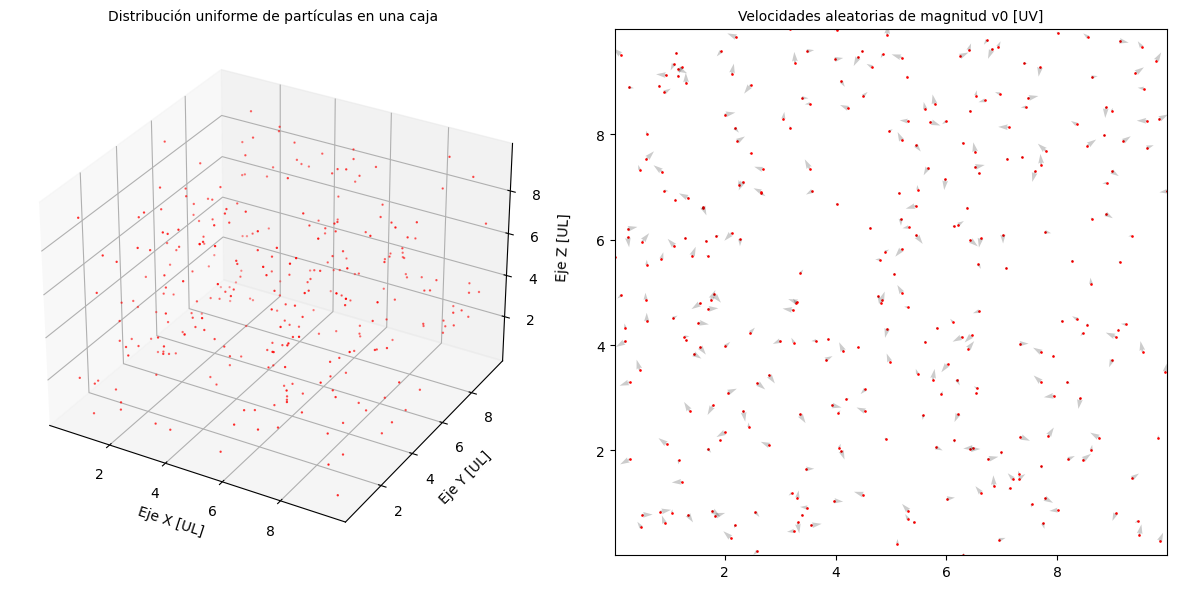

In [ ]:
mA = 1    # [UM] - Masa atómica
T = 1     # [UT] - Temperatura
L = 10    # [UL] - Longitud del lado
N = 300     # Nro. de partículas


# =================== Simulación del gas homogéneo en una caja de longitud L ===================
#
parts = pd.DataFrame(np.random.uniform(0,L,size=(N,3)),columns=['x','y','z'])   # Posición de las partículas

v0 = 1.0      # [UV] - Rapidez de cada partícula

# Para que la rapidez sea constante para cada partícula, generamos direcciones esféricas
#
phi = np.random.uniform(0, 2*np.pi, size=N)
theta = np.random.uniform(0, np.pi, size=N)

# Transformamos a las coordenadas cartesianas
vx = v0*np.sin(phi)*np.cos(theta)
vy = v0*np.sin(phi)*np.sin(theta)
vz = v0*np.cos(phi)

parts[['vx', 'vy', 'vz']] = pd.Series([vx, vy, vz])   # Velocidades aleatorias
parts['v'] = v0

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121, projection='3d')
ax.set_title('Distribución uniforme de partículas en una caja', fontsize=10)
ax.scatter(parts.x, parts.y, parts.z, color='r', s=0.5)
ax.margins(0,0,0)
ax.set_xlabel('Eje X [UL]')
ax.set_ylabel('Eje Y [UL]')
ax.set_zlabel('Eje Z [UL]')
fig.tight_layout()

ax = fig.add_subplot(122)
ax.set_title('Velocidades aleatorias de magnitud v0 [UV]', fontsize=10)
ax.scatter(parts.x, parts.y, color='r', s=0.8)
#ax.quiver(parts.x, parts.y, parts.z, parts.vx, parts.vy, parts.vz, length=0.4, color='k', alpha=0.1)
ax.quiver(parts.x, parts.y, parts.vx, parts.vy, scale=50, color='k', alpha=0.2)
ax.margins(0,0)
ax.set_ylabel('\n ')
fig.tight_layout()

3. Definir un paso de tiempo para realizar la simulación del movimiento de las partículas así:

   - Calcular $L_{mol}$ en la caja.
   - El paso de tiempo será $dt = (L_{mol}/v_0)/f_t$ donde $f_t = 10$. Puede hacer más pequeño o más grande $f_t$ de dependiendo de si la simulación tarda mucho tiempo en ejecutarse.



In [ ]:
V = L**3      # [UL^3] - Volumen de la caja
n = N/V       # [parts / UL^3] - Densidad del número de partículas
rho = n*mA    # [UM/UL^3] - Densidad

Vmol = 1/n    # [UL^3] - Volumen ocupado por cada partícula
Lmol = Vmol**(1/3)    # [UL] - Distancia media entre partículas

ft = 10
dt = (Lmol/v0)/ft    # Paso del tiempo

print('Distancia media entre partículas: %.2lf [UL]' %Lmol)
print('Diferencial de tiempo : Paso de tiempo para la simulación: %.2lf' %dt)

Distancia media entre partículas: 1.49 [UL]
Diferencial de tiempo : Paso de tiempo para la simulación: 0.15


## Simulación del movimiento de las partículas del gas.

Cada partícula tiene un movimiento rectilíneo uniforme, por lo que su evolución temporal está determinada por:

$$\vec r(t) = \vec r(t_0) + \vec v t$$

Sin embargo, las partículas en su movimiento pueden colisionar con otras y esto cambia su velocidad. Si asumimos que la colisión es elástica, valiéndonos de la fuente https://en.wikipedia.org/wiki/Elastic_collision, dos partículas de igual masa que chocan elásticamente en un instante de tiempo tendrán una velocidad final dada por:

$$\vec v_1' = \vec v_1 - \frac{ (\vec v_1 - \vec v_2) \cdot (\vec r_1 - \vec r_2)}{\Arrowvert \vec r_1 - \vec r_2 \Arrowvert^2} (\vec r_1 - \vec r_2)$$

$$\vec v_2' = \vec v_2 - \frac{ (\vec v_2 - \vec v_1) \cdot (\vec r_2 - \vec r_1)}{\Arrowvert \vec r_2 - \vec r_1 \Arrowvert^2} (\vec r_2 - \vec r_1)$$

La condición para que dos partículas de la caja choquen es que en un instante fijo, la distancia entre estas debe cumplir que: $\Arrowvert \vec r_1 - \vec r_2 \Arrowvert \leq dc$ donde $dc = L_{mol} / fd)$, $fd = 10$.

* $fd$ funciona como un escalador de esta distancia máxima de choque.

\
### Estrategia de simulación

Notemos que para analizar si una partícula colisiona con otra requiere que calculemos la distancia de todas las partículas con ella, y esto por cada instante de tiempo y para cada partícula. Esto implica que el tiempo de cómputo para la simulación puede tomar una gran cantidad de tiempo.

Sin embargo, este tiempo se puede reducir si sólo determinamos la distancia entre una partícula objetivo y las partículas más cercanas a ella. A continuación se detalla un modelo que desarrollé para llevar a cabo esta estrategia:

> **1)** Como primer paso, para determinar las partículas cercana a una partícula objetivo, pensemos en dividir la caja donde se ubican las partículas en mini-cubos de una longitud menor a la longitud de la caja, la cual está dada por:
>
> $$lado = L/ncx$$
>
> Donde $\bf ncx$ será el número de mini-longitudes en uno de los ejes (aprovechando que la caja es cúbica).
>
> La idea es que a cada uno de estos cubos se le determine la cantidad de partículas que tiene en su interior. Así, si me ubico en una de estas partículas, las partículas en el cubo son vecinas a ella y puedo determinar si colisiona sólo con estas, de manera que se excluyen todas las demás partículas de la caja.
>
> Sin embargo, si una partícula se encuentra en un extremo de su cubo, esta tendrá partículas vecinas ubicadas en otros cubos, por lo que es necesario también determinar las partículas en los cubos vecinos.
>
> Para hacer esto, la estrategia que utilicé consiste en asignar una identificación a los cubos dentro de la caja que contengan partículas en su interior. Aprovechando que $\bf ncx$ es la cantidad de cubos que hay en un eje (ej: 5), entonces contando cuántos cubos hay hacia los tres ejes para una determinada posición, puedo crear una identificación para los cubos como en el siguiente ejemplo:
>
> > Ejemplo: Si una partícula $p$ se ubica en la posición $\vec r_p = (x,y,z)$, ésta se encuentra en el cubo $(i,j,k)$:
> > ```
> > i = int(x/lado)
> > j = int(y/lado)
> > k = int(z/lado)
> > ```
>
> > La función ``` asignacion_cubos() ``` realiza este proceso.


> **2)** Con las mismas identificaciones de cada cubo determinamos los cubos vecinos. Para un cubo $(i,j,k)$, sus vecinos serán aquellos $(i', j', k')$ tal que:
> $i' \in [i-1, i, i+1]$
> $j' \in [j-1, j, j+1]$
> $k' \in [k-1, k, k+1]$
>
> **Nota**: Se debe verificar que estos índices no sean negativos ni mayores que $\bf ncx$ tal que sobresalgan de la caja.
>
> Con la ayuda de esto determinamos las partículas vecinas de una partícula objetivo, pues estos cubos guardan la identificación de las partículas que tienen adentro.
>
> > La función ``` ps_prob_choque() ``` realiza este proceso.

> **3)** Finalmente es posible calcular la distancia a las partículas vecinas y analizar si chocan.

> **Problema:** Si en un instante de tiempo, una partícula $p$ ya ha colisionado con una partícula $q$, cuando determinemos las vecinas de $q$ con las que posiblemente colisione para ese mismo tiempo, allí estará $p$, lo que implicaría una reversión de la colisión. Este problema se soluciona aprovechando el hecho de que este proceso se analiza comenzando desde la partícula $0$ hasta la $N$, de modo que, si una partícula $p$ colisiona con $q$, y $p<q$, cuando pasemos por $q$ se puede excluir $p$ con la condición de que $p<q$.
>
> Con esta condición se excluyen todas las partículas anteriores que se analizaron para un tiempo fijo. Esto se realiza en la función ``` ps_prob_choque() ```.


In [ ]:
# ============================= Modelo de distancias por cubos : LINKED LIST =============================
#
def asignacion_cubos(fd):
    dc = Lmol/fd
    ncx = int(L/dc//1.5)
    lado = L/ncx     # Medida del lado del cubo

    dic_cubos = {}
    id_cubos = np.zeros([N,3], dtype=int)    # Guarda la identificación de los cubos para cada part

    for p in range(len(parts)):
        # Cálculo del cubo donde se encuentra la partícula
        #
        i, j, k = int(parts.x[p]/lado), int(parts.y[p]/lado), int(parts.z[p]/lado)
        id_cubos[p] = i,j,k

        cubo = str(i) + str(j) + str(k)    # Agregamos la partícula al cubo 'ijk'

        # Inicializamos el diccionario con los identificadores de los cubos
        if cubo in dic_cubos:
            dic_cubos[cubo] += [p]
        else:
            dic_cubos[cubo] = [p]
    #
    parts[['i', 'j', 'k']] = id_cubos

    return dic_cubos, ncx


# Determinamos los cubos vecinos al cubo de una partícula ===========================================
#
def ps_prob_choque(p, dic_cubos, ncx):   # Parámetros: id de la part y su cubo
    #
    i,j,k = parts['i'][p], parts['j'][p], parts['k'][p]

    # Rutina para identificar los cubos vecinos al cubo de la part
    #
    id_cvecinos = []
    for i1 in range(i-1, i+2):
        for j1 in range(j-1, j+2):
            for k1 in range(k-1, k+2):
                #
                # Excluimos los índices negativos y mayores a ncx
                #
                if i1>=0 and j1>=0 and k1>=0 and i1<ncx and j1<ncx and k1<ncx:
                    id_cvecinos.append(str(i1) + str(j1) + str(k1))    # El dic_cubos recibe el identificador como cadena

    # Determinamos el índice de las partículas vecinas a p ubicadas en su cubo y los vecinos
    #
    id_vecis = []
    for id_c in id_cvecinos:
        if id_c in dic_cubos:         # Si existe el id en el diccionario de cubos
            id_ps = dic_cubos[id_c]   # Tomamos el id de las partículas ubicadas en los cubos vecinos de p

            # Excluimos las partículas que ya se han recorrido y probablemente colisionaron con p
            #
            inds = [ind for ind in id_ps if ind > p]
            id_vecis += inds

    return id_vecis


# Cálculo de la interacción de la partícula p con las demás en sus cubos vecinos ==============================
#
def interaccion(p, dic_cubos, ncx, fd):
    dc = Lmol/fd      # Distancia mínima de colisión
    #
    datas_p = np.array(parts.iloc[p])   # Datos de la partícula p
    r = datas_p[0:3]          # Posición
    v = datas_p[3:6]          # Velocidad

    idqs = ps_prob_choque(p, dic_cubos, ncx)    # DataFrame de las partículas con las probablemente choque

    # COLISIÓN ELÁSTICA dado el caso
    for q in idqs:
        #
        datas_q = np.array(parts.iloc[q])
        rq, vq = datas_q[0:3], datas_q[3:6]   # Posiciones y velocidades de la part. q

        dist = np.linalg.norm(r-rq)         # Distancia entre las partículas vecinas a p

        if dist <= dc:
            # Hay colisión elástica -> Determinamos las velocidades después de la colisión
            #
            v_up = v - np.dot(v-vq, r-rq)/np.linalg.norm(r-rq)**2*(r-rq)
            vq_up = vq - np.dot(vq-v, rq-r)/np.linalg.norm(rq-r)**2*(rq-r)

            parts.loc[q, ['vx', 'vy', 'vz']] = vq_up    # Actualizamos las velocidades de p y q
            parts.loc[p, 'v'] = np.linalg.norm(vq_up)
            parts.loc[p, ['vx', 'vy', 'vz']] = v_up
            parts.loc[p, 'v'] = np.linalg.norm(v_up)
#
# fin interacción ===================================================================

## Simulación e histogramas de rapidez

In [ ]:
!pip install celluloid &> /dev/null

from celluloid import Camera
from IPython.display import HTML

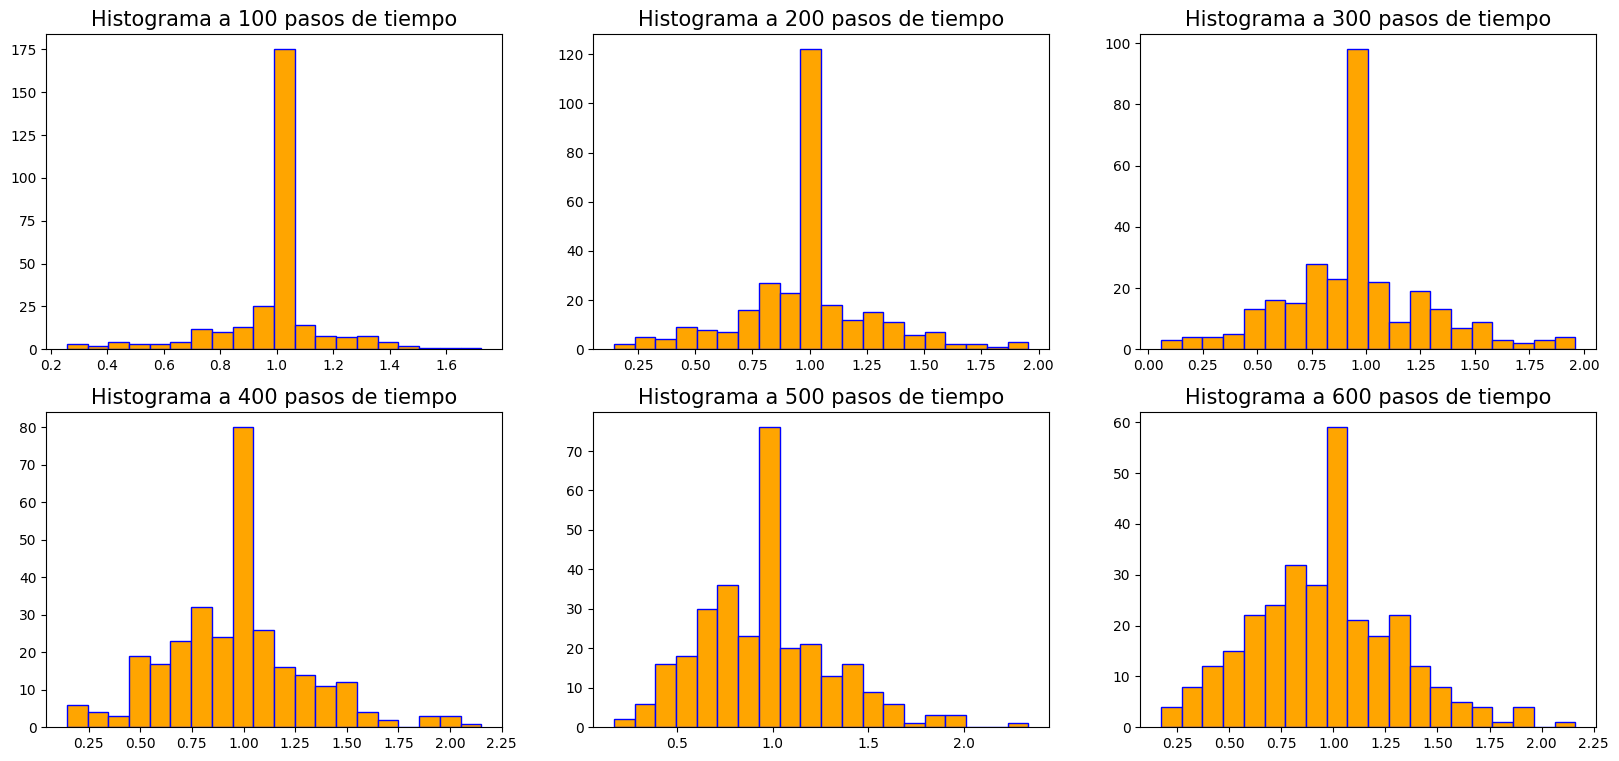

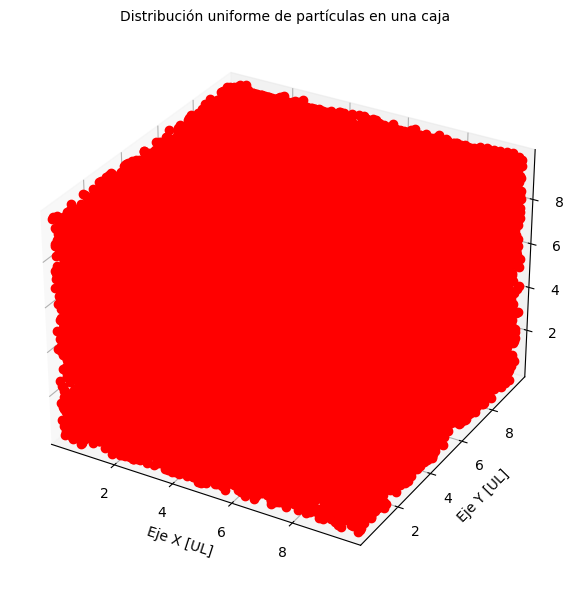

In [ ]:
import time
inicio = time.time()

fd = 5
Nt = 600
# ts = np.arange(0, Nt+dt, dt)

def histograma(f,c, t):
    axes[f][c].hist(parts.v, bins=20, color='orange', edgecolor='b')
    axes[f][c].set_title('Histograma a %d pasos de tiempo' %t, fontsize=15)
#
#===============================================================================
fig, axes = plt.subplots(2,3)   # Figura para almacenar los histogramas
fig.set_size_inches(20,9)
f, c = 0,0

# Simulación con Celluloid =====================================================
fig2 = plt.figure(figsize=(12,6))
ax = fig2.add_subplot(111, projection='3d')
ax.set_title('Distribución uniforme de partículas en una caja', fontsize=10)
#
camera = Camera(fig2)

# Densidad de energía cinética del gas para cada t
Ks = np.zeros(Nt)

for t in range(Nt):
# ax.scatter(parts.x, parts.y, parts.z, color='r', s=0.5)

    # Gráfico de dispersión
    ax.plot(parts.x, parts.y, parts.z, 'o', color='r')
    camera.snap()

    Ks[t] = (0.5*mA*parts.v**2).mean()

    dic_cubos, ncx = asignacion_cubos(fd)

    parts2 = parts.copy()
    for p in range(N):
        interaccion(p, dic_cubos, ncx, fd)

        # Evoluciono la partícula en el tiempo
        #
        xu = parts.x[p] + parts.vx[p]*dt
        yu = parts.y[p] + parts.vy[p]*dt
        zu = parts.z[p] + parts.vz[p]*dt

        # Condiciones de frontera periódica
        #
        if xu<0:
            xu = xu + (abs(int(xu/L))+1)*L
        elif xu > L:
            xu = xu - int(xu/L)*L
        #
        if yu<0:
            yu = yu + (abs(int(yu/L))+1)*L
        elif yu > L:
            yu = yu - int(yu/L)*L
        #
        if zu<0:
            zu = zu + (abs(int(zu/L))+1)*L
        elif zu > L:
            zu = zu - int(zu/L)*L

        # La evolución se agrega a un nuevo DataFrame tq. no arruine la interacción de las demás partículas
        #
        parts2.loc[p, ['x', 'y', 'z']] = np.array([xu, yu, zu])

        # Agregamos también la velocidad final con la que p quedó después de todas sus interacciones
        parts2.loc[p, ['vx', 'vy', 'vz']] = parts.loc[p, ['vx', 'vy', 'vz']]
        parts2.loc[p, 'v'] = parts['v'][p]

    parts = parts2.copy()

    # Graficación de histogramas de velocidades =========================================
    #
    if (t+1)%int(Nt/6) == 0:
        histograma(f,c,t+1)
        c += 1
        if c == 3:
            f += 1
            c = 0
# Fin simulación ===============================================================

ax.margins(0,0,0)
ax.set_xlabel('Eje X [UL]')
ax.set_ylabel('Eje Y [UL]')
ax.set_zlabel('Eje Z [UL]')
fig2.tight_layout()
fig2.show(False)

fin = time.time()

In [ ]:
tiempo_transcurrido = fin - inicio
print("\nTiempo de ejecución:", tiempo_transcurrido, "segundos")


Tiempo de ejecución: 712.729478597641 segundos


In [ ]:
animation = camera.animate(blit=True, interval=300)
HTML(animation.to_html5_video())

Output hidden; open in https://colab.research.google.com to view.

## Temperatura y Presión

De acuerdo a la teoría de la mecánica estadística, para un gas monoatómico cuyas partículas sólo tienen energía cinética de traslación:

> La energía cinética de cada partícula está dada por: $$k = \frac{1}{2} m_A v^2$$

> La densidad de energía cinética de las partículas está dada por el promedio de las energías cinéticas:

$$\langle K \rangle = 3 k_B T / 2 $$

  * De esta se puede determinar la temperatura del gas.

> La presión del gas está dada por: $$P = 2/3 n \langle K \rangle = n k_B T$$

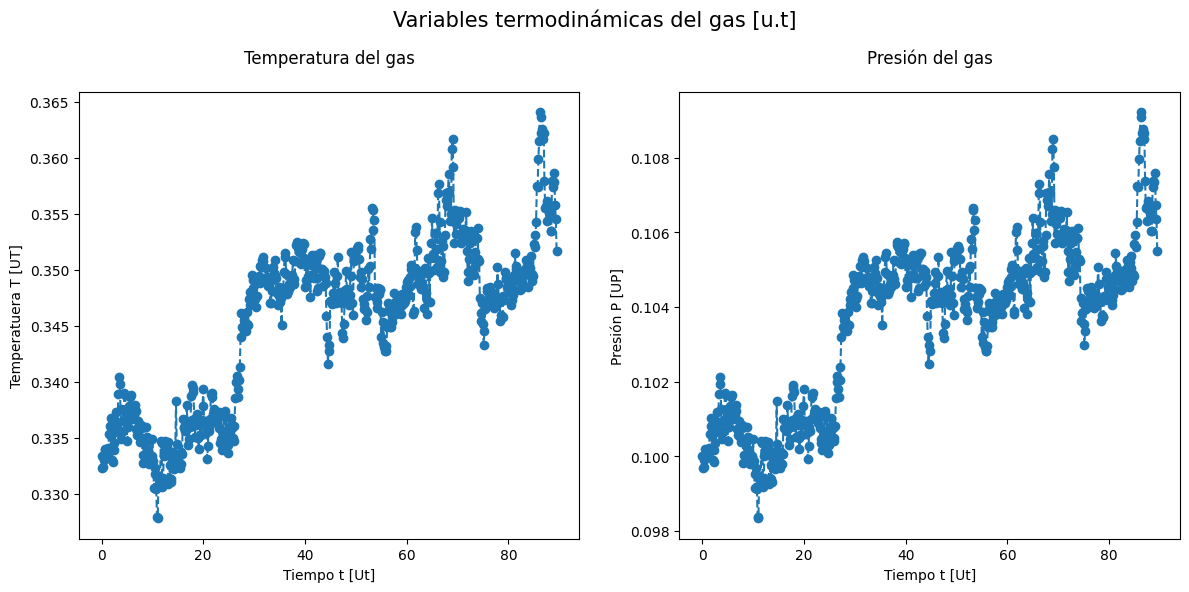

In [ ]:
Ts = 2*Ks/(3*KB)
Ps = 2/3*n*Ks

ts = np.zeros(Nt)
for i in range(Nt):
    ts[i] = i*dt

fig, (gT, gP) = plt.subplots(1,2)
fig.suptitle('Variables termodinámicas del gas [u.t]', fontsize=15)
fig.set_size_inches(12, 6)

gT.set_title('Temperatura del gas\n', fontsize=12)
gT.plot(ts, Ts, 'o--')
gT.set_xlabel('Tiempo t [Ut]')
gT.set_ylabel('Temperatuera T [UT]')

gP.set_title('Presión del gas\n', fontsize=12)
gP.plot(ts, Ps, 'o--')
gP.set_xlabel('Tiempo t [Ut]')
gP.set_ylabel('\nPresión P [UP]')

fig.tight_layout()